In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn imports for dataset, model, and metrics
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

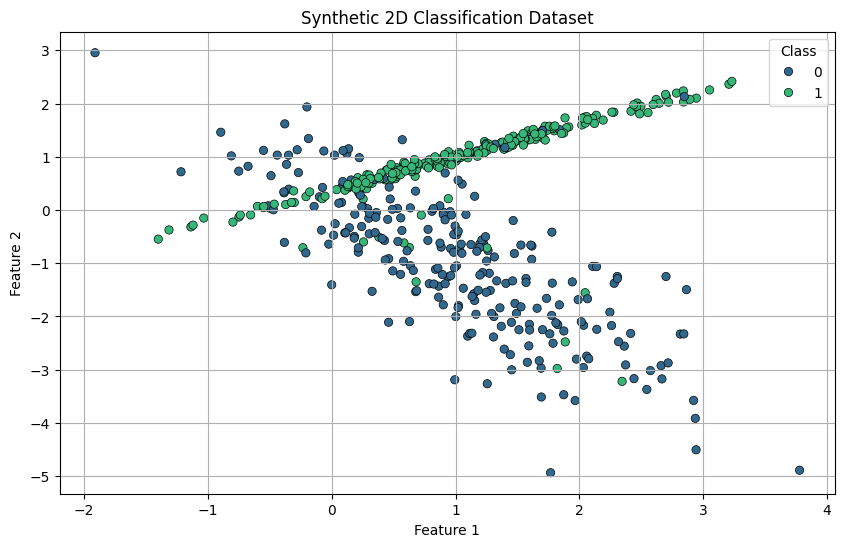

In [ ]:
# Generate a synthetic dataset
X, y = make_classification(
    n_samples=500,          # 500 data points
    n_features=2,           # 2 features for easy visualization
    n_informative=2,        # Both features are useful
    n_redundant=0,          # No redundant features
    n_clusters_per_class=1, # One cluster per class
    flip_y=0.1,             # Add some noise to make it challenging
    random_state=42         # for reproducibility
)

# Visualize the dataset
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', edgecolor='k')
plt.title("Synthetic 2D Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend(title="Class")
plt.grid(True)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (350, 2)
Testing set shape: (150, 2)


In [ ]:
# 1. Define the weak learner (a Decision Stump)
# This is a simple decision tree that makes a single split.
weak_learner = DecisionTreeClassifier(max_depth=1, random_state=42)

# 2. Define and train the AdaBoost model
# n_estimators: The number of weak learners to train sequentially.
# learning_rate: Shrinks the contribution of each classifier.
ada_model = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

# Train the model on the training data
print("Training the AdaBoost model...")
ada_model.fit(X_train, y_train)
print("Training complete.")

Training the AdaBoost model...
Training complete.


AdaBoost Model Accuracy: 0.8133

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.72      0.79        74
           1       0.77      0.91      0.83        76

    accuracy                           0.81       150
   macro avg       0.82      0.81      0.81       150
weighted avg       0.82      0.81      0.81       150



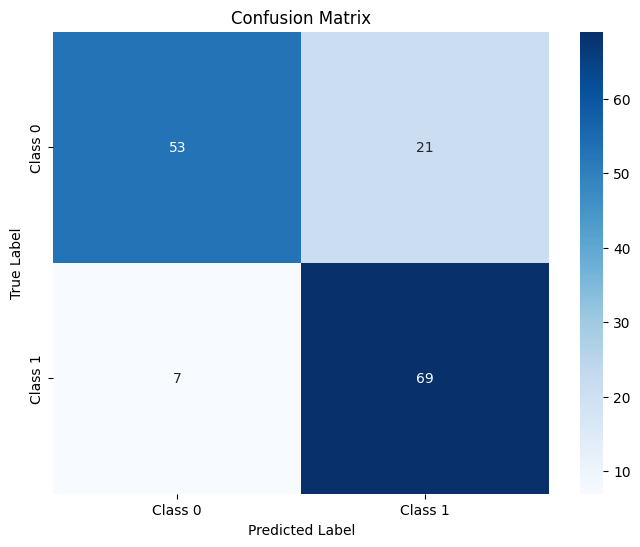

In [ ]:
# Make predictions on the test set
y_pred = ada_model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"AdaBoost Model Accuracy: {accuracy:.4f}\n")

# Display the classification report
print("Classification Report:")
print(classification_report(y_test, y_pred))

# Display the confusion matrix with a heatmap for better visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1'],
            yticklabels=['Class 0', 'Class 1'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

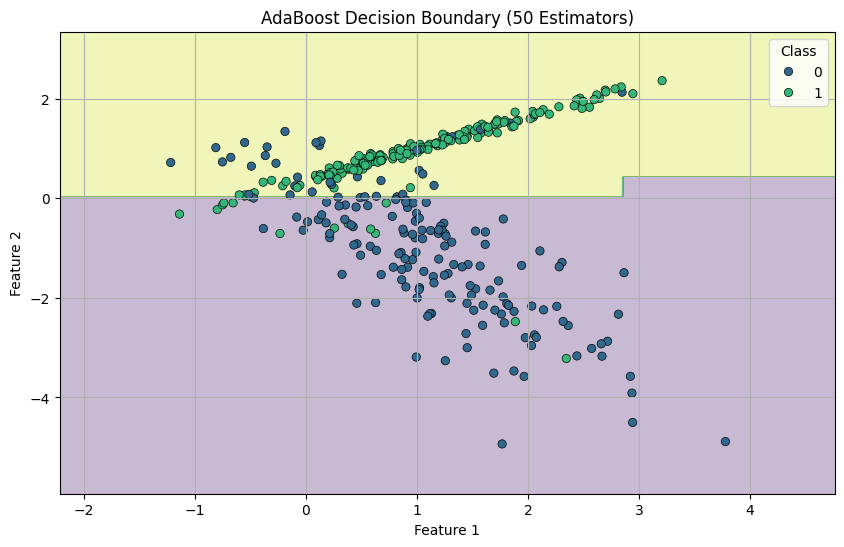

In [ ]:
def plot_decision_boundary(clf, X, y, title):
    """
    Plots the decision boundary of a classifier.
    """
    # Create a meshgrid of points to plot the decision boundary
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    # Predict the class for each point in the meshgrid
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Plot the contour and the training points
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=y, palette='viridis', edgecolor='k')
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend(title="Class")
    plt.grid(True)
    plt.show()

# Visualize the decision boundary of the final AdaBoost model
plot_decision_boundary(ada_model, X_train, y_train, "AdaBoost Decision Boundary (50 Estimators)")

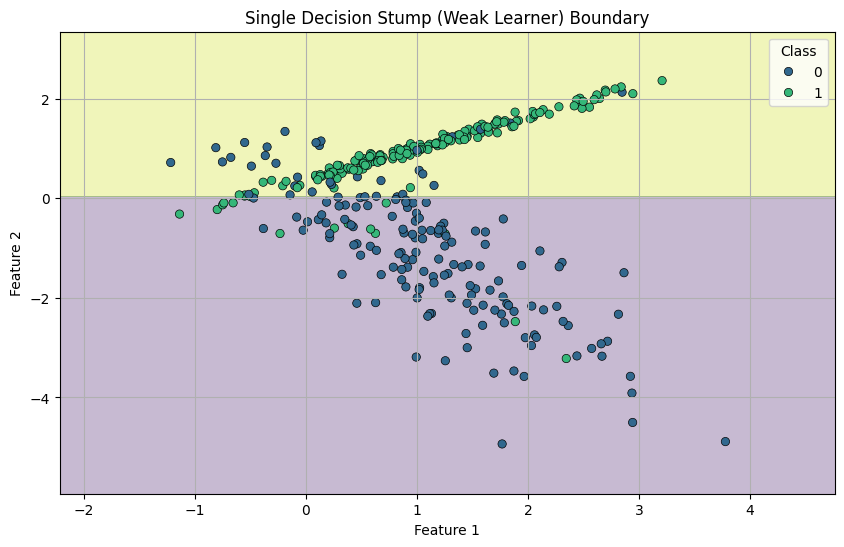

Single Decision Stump Accuracy: 0.8133


In [ ]:
# Train a single Decision Stump on the data
single_stump = DecisionTreeClassifier(max_depth=1, random_state=42)
single_stump.fit(X_train, y_train)

# Visualize its decision boundary
plot_decision_boundary(single_stump, X_train, y_train, "Single Decision Stump (Weak Learner) Boundary")

# Evaluate its accuracy
y_pred_stump = single_stump.predict(X_test)
accuracy_stump = accuracy_score(y_test, y_pred_stump)
print(f"Single Decision Stump Accuracy: {accuracy_stump:.4f}")